## MODULE 5: Performance Trend Analysis


In [1]:
import pandas as pd
df = pd.read_excel("final_clustered_dataset.xlsx")
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,Time to Resolution,Resolution_Time_Hours,Response_Efficiency_%,Priority_Score,Resolution_Category,Cluster_ID,Cluster_Name,Similarity_Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,NaT,NaN,NaN,4,Pending,3,Pending Cluster,0.0000
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,NaT,NaN,NaN,4,Pending,3,Pending Cluster,0.0000
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 18:05:38,18.09,0.165837,1,Slow,2,Slow Resolution Cluster,0.0553
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 01:57:40,1.96,1.530612,1,Fast,0,Fast Resolution Cluster,0.5102
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 19:53:42,19.90,0.150754,1,Slow,2,Slow Resolution Cluster,0.0503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaN,NaN,1,Pending,3,Pending Cluster,0.0000
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaN,NaN,4,Pending,3,Pending Cluster,0.0000
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 04:31:22,4.52,0.663717,3,Medium,1,Medium Resolution Cluster,0.2212
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 05:32:24,5.54,0.541516,2,Medium,1,Medium Resolution Cluster,0.1805


In [2]:
priority_resolution = df.groupby('Ticket Priority')['Resolution_Time_Hours'].mean().round(2)

print(priority_resolution)

Ticket Priority
Critical    12.01
High        11.87
Low         12.46
Medium      11.57
Name: Resolution_Time_Hours, dtype: float64


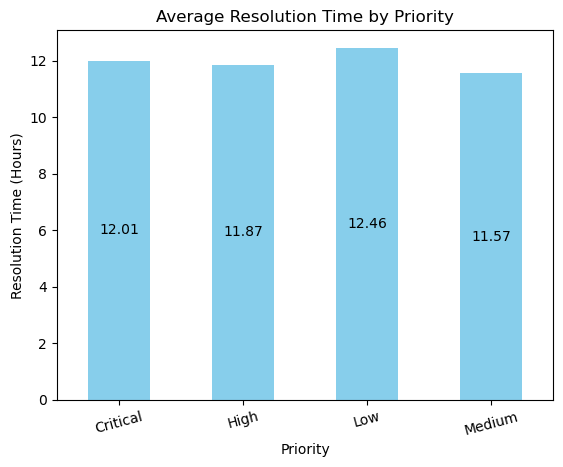

In [3]:
import matplotlib.pyplot as plt

ax = priority_resolution.plot(kind='bar', color='skyblue')

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Resolution Time (Hours)")

for container in ax.containers:
    ax.bar_label(container, label_type="center")

plt.xticks(rotation=15)

plt.show()

In [4]:
type_resolution = df.groupby('Ticket Type')['Resolution_Time_Hours'].mean().round(2)

print(type_resolution)

Ticket Type
Billing inquiry         11.78
Cancellation request    12.05
Product inquiry         12.38
Refund request          12.01
Technical issue         11.65
Name: Resolution_Time_Hours, dtype: float64


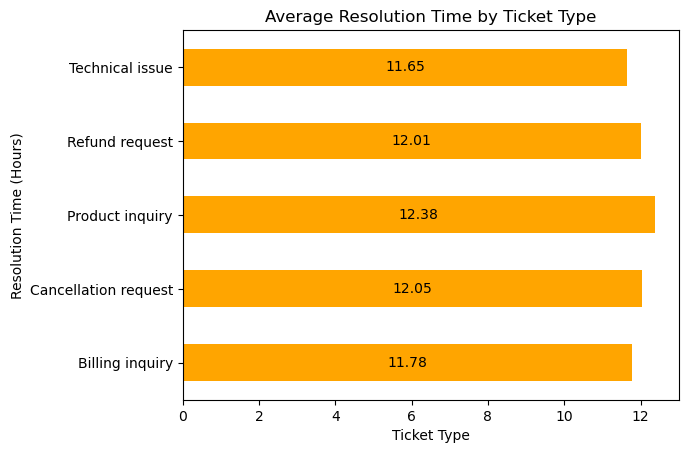

In [5]:
ax = type_resolution.plot(kind='barh', color='orange')

plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Resolution Time (Hours)")

for container in ax.containers:
    ax.bar_label(container, label_type="center")

plt.show()

In [6]:
high_priority_pending = df[
    (df['Ticket Priority'].isin(['High', 'Critical'])) &
    (df['Resolution_Category'] == 'Pending')
]

print("Number of High-Priority Unresolved Tickets:", len(high_priority_pending))

Number of High-Priority Unresolved Tickets: 2783


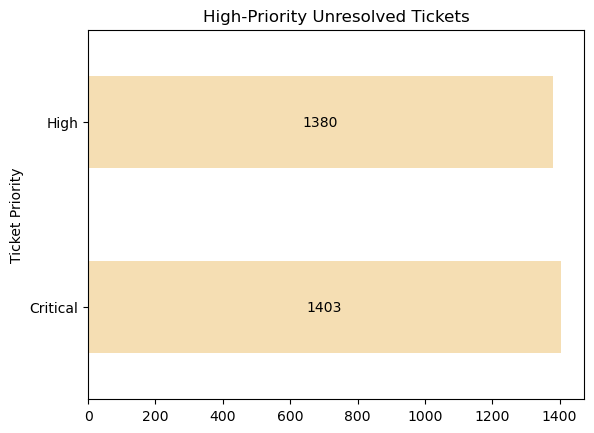

In [7]:
ax = high_priority_pending['Ticket Priority'].value_counts().plot(kind='barh', color='wheat')

plt.title("High-Priority Unresolved Tickets")

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.show()


## MODULE 6: Category-Level Insights

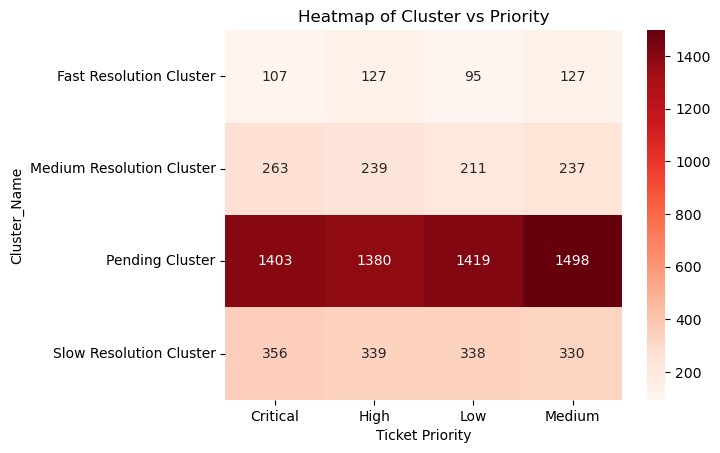

In [8]:
import seaborn as sns

heatmap_data = pd.crosstab(df['Cluster_Name'], df['Ticket Priority'])

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds')

plt.title("Heatmap of Cluster vs Priority")
plt.show()


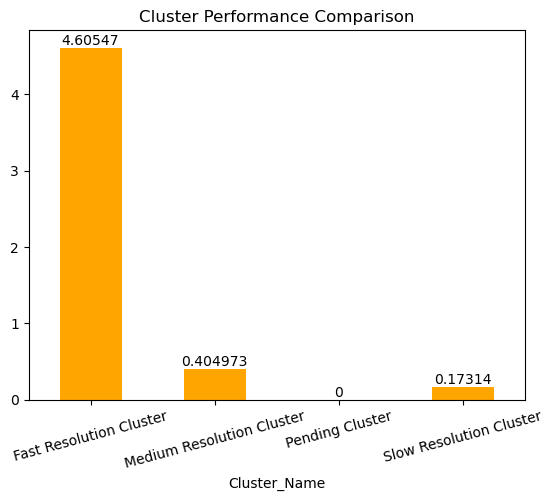

In [9]:
cluster_perf = df.groupby('Cluster_Name')['Response_Efficiency_%'].mean()

ax = cluster_perf.plot(kind='bar', color='orange')

plt.title("Cluster Performance Comparison")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.show()

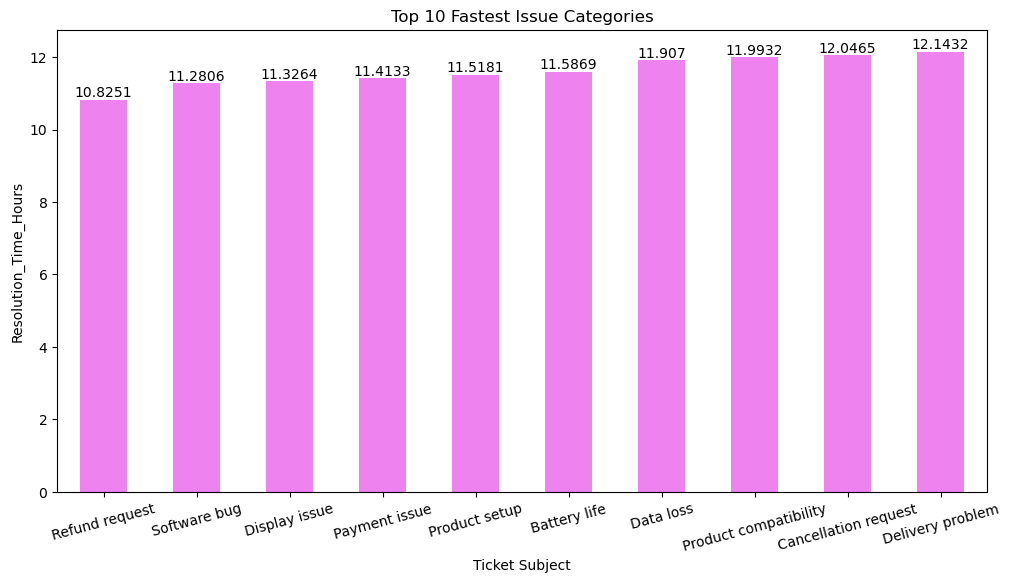

In [10]:
category_perf = df.groupby('Ticket Subject')['Resolution_Time_Hours'].mean().sort_values().head(10)

plt.figure(figsize=(12,6))

ax = category_perf.plot(kind='bar', color='violet')

plt.title("Top 10 Fastest Issue Categories")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.ylabel("Resolution_Time_Hours")

plt.show()


## Performance Trend Analysis Insights

- Critical priority tickets have the highest average resolution time, indicating higher complexity.
- Fast Resolution Cluster demonstrates highest efficiency.
- Slow Resolution Cluster indicates performance bottlenecks.
- High-priority unresolved tickets represent critical backlog risks.
- Performance varies significantly across issue categories.


In [11]:
kpi_summary = {
    "Average Resolution Time (Hours)": df['Resolution_Time_Hours'].mean(),
    "Average Response Efficiency (%)": df['Response_Efficiency_%'].mean(),
    "Total Tickets": len(df),
    "Resolved Tickets": df['Resolution_Category'].isin(['Fast','Medium','Slow']).sum(),
    "Pending Tickets": (df['Resolution_Category'] == 'Pending').sum(),
    "Most Frequent Issue": df['Ticket Subject'].mode()[0],
    "Best Performing Cluster": df.groupby('Cluster_Name')['Response_Efficiency_%'].mean().idxmax()
}

kpi_summary = pd.DataFrame(list(kpi_summary.items()), columns=['KPI','Value'])

print(kpi_summary)


                               KPI                    Value
0  Average Resolution Time (Hours)                11.969657
1  Average Response Efficiency (%)                 0.981288
2                    Total Tickets                     8469
3                 Resolved Tickets                     2769
4                  Pending Tickets                     5700
5              Most Frequent Issue           Refund request
6          Best Performing Cluster  Fast Resolution Cluster


In [12]:
kpi_summary.to_excel("kpi_summary.xlsx", index=False)

In [13]:
df.to_excel("dashboard_dataset.xlsx", index=False)